# Day 2 — Methane Calibration Transfer Baseline

Project: **MOx Calibration Transfer for Combible Gas**  
Dataset: **UCI #361 Twin Gas Sensor Arrays**  
Gas: **Methane (`GMe`)**

Day 2 scope only:

1. Build unified methane dataframe
2. Extract raw and physics-informed features
3. Split by board: train `B1 B2 B3`, validation `B4`, test `B5`
4. Train lightweight baseline models
5. Compare raw vs physics-informed vs combined features
6. Quantify transfer failure on B5
7. Save all outputs under `figures/day2` and `results/day2`

No deep learning, no transformers, no Day 3 adaptation.

In [1]:
import sys
print(sys.executable)

C:\Users\hg\PycharmProjects\mox_calibration_transfer\.venv\Scripts\python.exe


In [2]:
from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

# ADD THIS
from xgboost import XGBRegressor, XGBClassifier

warnings.filterwarnings('ignore')

# Locate project root. This notebook is expected to live in notebooks/.
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == 'notebooks':
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_RAW = PROJECT_ROOT / 'data' / 'raw'

FIG_DIR = PROJECT_ROOT / 'figures' / 'day2'
RES_DIR = PROJECT_ROOT / 'results' / 'day2'

FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_RAW     =', DATA_RAW)
print('FIG_DIR      =', FIG_DIR)
print('RES_DIR      =', RES_DIR)

PROJECT_ROOT = C:\Users\hg\PycharmProjects\mox_calibration_transfer
DATA_RAW     = C:\Users\hg\PycharmProjects\mox_calibration_transfer\data\raw
FIG_DIR      = C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2
RES_DIR      = C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2


## 1. File discovery and metadata parsing

Expected filename pattern:

```text
B1_GMe_F010_R1.txt
```

where:

- `B1` = board
- `GMe` = methane
- `F010` = concentration label
- `R1` = replicate

In [3]:
FILENAME_RE = re.compile(
    r'(?P<board>B\d+)_(?P<gas>G[A-Za-z0-9]+)_(?P<conc>F\d+)_(?P<rep>R\d+)\.txt$',
    re.IGNORECASE,
)

def parse_filename(path: Path):
    m = FILENAME_RE.search(path.name)
    if m is None:
        return None
    d = m.groupdict()
    d['file'] = str(path)
    d['filename'] = path.stem
    d['concentration_numeric'] = int(d['conc'].upper().replace('F', ''))
    return d

all_txt = sorted(DATA_RAW.glob('*.txt'))
records = []
for p in all_txt:
    meta = parse_filename(p)
    if meta is not None:
        records.append(meta)

file_index = pd.DataFrame(records)
if file_index.empty:
    raise FileNotFoundError(
        f'No parsable .txt files found in {DATA_RAW}. '
        'Place UCI #361 raw files under data/raw before running this notebook.'
    )

methane_files = file_index[file_index['gas'].str.upper() == 'GME'].copy()
print('Total parsed files:', len(file_index))
print('Methane files:', len(methane_files))
display(methane_files.head())
print(methane_files.groupby(['board', 'concentration_numeric']).size().unstack(fill_value=0))

Total parsed files: 640
Methane files: 160


,board,gas,conc,rep,file,filename,concentration_numeric
120,B1,GMe,F010,R1,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F010_R1,10
121,B1,GMe,F010,R2,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F010_R2,10
122,B1,GMe,F010,R3,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F010_R3,10
123,B1,GMe,F010,R4,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F010_R4,10
124,B1,GMe,F020,R1,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F020_R1,20


concentration_numeric  10   20   30   40   50   60   70   80   90   100
board                                                                  
B1                       4    4    4    4    4    4    4    4    4    4
B2                       4    4    4    4    4    4    4    4    4    4
B3                       4    4    4    4    4    4    4    4    4    4
B4                       2    2    2    2    2    2    2    2    2    2
B5                       2    2    2    2    2    2    2    2    2    2


## 2. Load methane time series

File format from Day 1:

- column 0 = time
- columns 1–8 = sensor channels
- sampling interval = 0.01 s

In [4]:
def load_sensor_file(path: Path) -> pd.DataFrame:
    """Load one raw UCI #361 txt file.

    The loader is deliberately permissive about delimiters because UCI text files
    may be whitespace- or comma-separated depending on how they were saved.
    """
    df = pd.read_csv(path, sep=r'\s+|,|;', engine='python', header=None, comment='#')
    if df.shape[1] < 9:
        raise ValueError(f'Expected at least 9 columns in {path}, got {df.shape[1]}')
    df = df.iloc[:, :9].copy()
    df.columns = ['time'] + [f's{i}' for i in range(1, 9)]
    return df.apply(pd.to_numeric, errors='coerce')

# quick smoke test
sample_path = Path(methane_files.iloc[0]['file'])
sample_ts = load_sensor_file(sample_path)
print(sample_path.name, sample_ts.shape)
display(sample_ts.head())

B1_GMe_F010_R1.txt (59995, 9)


,time,s1,s2,s3,s4,s5,s6,s7,s8
0,0.00,38.91,18.51,21.60,5.43,72.20,45.08,55.26,6.8
1,0.01,38.91,18.51,21.60,5.44,72.20,45.27,55.26,6.8
2,0.02,38.91,18.53,21.60,5.43,72.41,45.18,55.26,6.8
3,0.03,38.99,18.56,21.60,5.43,72.20,45.18,55.26,6.8
4,0.04,38.91,18.53,21.63,5.43,72.20,45.18,55.26,6.8


## 3. Feature extraction

Feature windows are intentionally simple and transparent.

Defaults:

- baseline window: first 10% of trace
- response window: full trace minimum/maximum statistics
- recovery window: last 20% of trace

For MOx reducing-gas exposure, resistance often decreases, so the response magnitude is defined as:

```text
response_magnitude = baseline_mean - minimum_response
```

This keeps larger positive values aligned with stronger downward responses.

In [5]:
def safe_slope(x: np.ndarray, y: np.ndarray) -> float:
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    return float(np.polyfit(x[mask], y[mask], 1)[0])


def extract_features_one_channel(time, y, prefix, baseline_frac=0.10, recovery_frac=0.20):
    time = np.asarray(time, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(y)
    b_end = max(5, int(n * baseline_frac))
    r_start = max(0, int(n * (1 - recovery_frac)))

    baseline = y[:b_end]
    recovery_y = y[r_start:]
    recovery_t = time[r_start:]
    dy = np.gradient(y, time) if n >= 3 and np.nanstd(time) > 0 else np.full_like(y, np.nan)

    baseline_mean = np.nanmean(baseline)
    minimum_response = np.nanmin(y)
    maximum_response = np.nanmax(y)
    final_value = y[-1] if n else np.nan

    response_magnitude = baseline_mean - minimum_response
    normalized_response = response_magnitude / baseline_mean if np.isfinite(baseline_mean) and baseline_mean != 0 else np.nan
    rs_r0_min = minimum_response / baseline_mean if np.isfinite(baseline_mean) and baseline_mean != 0 else np.nan
    rs_r0_final = final_value / baseline_mean if np.isfinite(baseline_mean) and baseline_mean != 0 else np.nan

    feats = {
        # raw features
        f'{prefix}_raw_mean': np.nanmean(y),
        f'{prefix}_raw_std': np.nanstd(y),
        f'{prefix}_raw_min': minimum_response,
        f'{prefix}_raw_max': maximum_response,
        f'{prefix}_raw_median': np.nanmedian(y),
        f'{prefix}_raw_q10': np.nanquantile(y, 0.10),
        f'{prefix}_raw_q90': np.nanquantile(y, 0.90),
        f'{prefix}_raw_final': final_value,
        f'{prefix}_raw_early_mean': np.nanmean(y[:b_end]),
        f'{prefix}_raw_late_mean': np.nanmean(recovery_y),

        # physics-informed features
        f'{prefix}_phys_baseline_mean': baseline_mean,
        f'{prefix}_phys_minimum_response': minimum_response,
        f'{prefix}_phys_normalized_response': normalized_response,
        f'{prefix}_phys_rs_r0_min': rs_r0_min,
        f'{prefix}_phys_rs_r0_final': rs_r0_final,
        f'{prefix}_phys_response_magnitude': response_magnitude,
        f'{prefix}_phys_recovery_slope': safe_slope(recovery_t, recovery_y),
        f'{prefix}_phys_derivative_mean': np.nanmean(dy),
        f'{prefix}_phys_derivative_std': np.nanstd(dy),
        f'{prefix}_phys_derivative_min': np.nanmin(dy),
        f'{prefix}_phys_derivative_max': np.nanmax(dy),
    }
    return feats


def extract_features_one_file(row) -> dict:
    path = Path(row['file'])
    ts = load_sensor_file(path)
    out = {
        'file': str(path),
        'filename': row['filename'],
        'board': row['board'],
        'gas': row['gas'],
        'concentration': row['conc'],
        'concentration_numeric': row['concentration_numeric'],
        'replicate': row['rep'],
        'n_points': len(ts),
        'duration_s': float(ts['time'].iloc[-1] - ts['time'].iloc[0]),
    }
    for i in range(1, 9):
        out.update(extract_features_one_channel(ts['time'].values, ts[f's{i}'].values, f's{i}'))
    return out

feature_rows = []
for _, row in methane_files.iterrows():
    try:
        feature_rows.append(extract_features_one_file(row))
    except Exception as e:
        print('FAILED:', row['file'], e)

features = pd.DataFrame(feature_rows)
features.to_csv(RES_DIR / 'feature_table_methane.csv', index=False)
print('Feature table:', features.shape)
display(features.head())

Feature table: (160, 177)


,file,filename,board,gas,concentration,concentration_numeric,replicate,n_points,duration_s,s1_raw_mean,...,s8_phys_minimum_response,s8_phys_normalized_response,s8_phys_rs_r0_min,s8_phys_rs_r0_final,s8_phys_response_magnitude,s8_phys_recovery_slope,s8_phys_derivative_mean,s8_phys_derivative_std,s8_phys_derivative_min,s8_phys_derivative_max
0,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F010_R1,B1,GMe,F010,10,R1,59995,599.99,37.220347,...,6.53,0.040004,0.959996,0.998220,0.272110,-0.000157,-0.000030,0.372281,-1.5,1.500000
1,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F010_R2,B1,GMe,F010,10,R2,59950,599.99,33.910132,...,6.45,0.057922,0.942078,1.007805,0.396565,-0.000161,0.000005,0.413261,-1.5,1.500000
2,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F010_R3,B1,GMe,F010,10,R3,59999,599.98,39.762511,...,7.68,0.047596,0.952404,1.009450,0.383801,0.000047,0.000133,0.420658,-1.5,1.500000
3,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F010_R4,B1,GMe,F010,10,R4,59859,599.99,38.070450,...,7.91,0.029414,0.970586,0.997581,0.239716,-0.000376,0.000096,0.513439,-2.0,2.166667
4,C:\Users\hg\PycharmProjects\mox_calibration_tr...,B1_GMe_F020_R1,B1,GMe,F020,20,R1,59979,599.99,36.109566,...,6.22,0.087262,0.912738,1.012523,0.594657,0.000308,0.000073,0.384588,-1.5,1.500000


## 4. Define feature sets and board split

Transfer split:

- train: `B1`, `B2`, `B3`
- validation: `B4`
- test: `B5`

In [6]:
raw_cols = [c for c in features.columns if '_raw_' in c]
phys_cols = [c for c in features.columns if '_phys_' in c]
combined_cols = raw_cols + phys_cols

split_map = {
    'B1': 'train', 'B2': 'train', 'B3': 'train',
    'B4': 'validation',
    'B5': 'test',
}
features['split'] = features['board'].map(split_map).fillna('unused')
features.to_csv(RES_DIR / 'feature_table_methane.csv', index=False)

print('Raw features:', len(raw_cols))
print('Physics-informed features:', len(phys_cols))
print(features.groupby(['split', 'board']).size())

train_df = features[features['split'] == 'train'].copy()
val_df = features[features['split'] == 'validation'].copy()
test_df = features[features['split'] == 'test'].copy()

assert not train_df.empty, 'Train split is empty.'
assert not val_df.empty, 'Validation split is empty.'
assert not test_df.empty, 'Test split is empty.'

Raw features: 80
Physics-informed features: 88
split       board
test        B5       20
train       B1       40
            B2       40
            B3       40
validation  B4       20
dtype: int64


## 5. Regression baselines

Models:

- Linear Regression
- RandomForestRegressor
- optional XGBoost if installed

Target: numeric concentration code extracted from `Fxxx`.

In [7]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def eval_regression(model_name, feature_set_name, y_true, y_pred, split):
    return {
        'task': 'regression',
        'model': model_name,
        'feature_set': feature_set_name,
        'split': split,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }

regressors = {
    'LinearRegression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ]),
    'RandomForestRegressor': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=2)),
    ]),
}

try:
    from xgboost import XGBRegressor
    regressors['XGBRegressor'] = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            random_state=42,
        )),
    ])
    print('XGBoost detected and enabled.')
except Exception:
    print('XGBoost not available; skipping optional XGBRegressor.')

feature_sets = {
    'raw': raw_cols,
    'physics': phys_cols,
    'combined': combined_cols,
}

y_train = train_df['concentration_numeric'].values
y_val = val_df['concentration_numeric'].values
y_test = test_df['concentration_numeric'].values

metrics = []
prediction_frames = []
fitted_models = {}

for fs_name, cols in feature_sets.items():
    X_train = train_df[cols]
    X_val = val_df[cols]
    X_test = test_df[cols]

    for model_name, model in regressors.items():
        model.fit(X_train, y_train)
        fitted_models[('regression', model_name, fs_name)] = model

        for split_name, df_split, X_split, y_split in [
            ('validation_B4', val_df, X_val, y_val),
            ('test_B5', test_df, X_test, y_test),
        ]:
            pred = model.predict(X_split)
            metrics.append(eval_regression(model_name, fs_name, y_split, pred, split_name))
            tmp = df_split[['filename', 'board', 'concentration', 'concentration_numeric', 'replicate']].copy()
            tmp['task'] = 'regression'
            tmp['model'] = model_name
            tmp['feature_set'] = fs_name
            tmp['split_eval'] = split_name
            tmp['y_true'] = y_split
            tmp['y_pred'] = pred
            tmp['error'] = tmp['y_pred'] - tmp['y_true']
            prediction_frames.append(tmp)

metrics_df = pd.DataFrame(metrics)
preds_df = pd.concat(prediction_frames, ignore_index=True)
metrics_df.to_csv(RES_DIR / 'metrics_regression.csv', index=False)
preds_df[preds_df['split_eval'] == 'test_B5'].to_csv(RES_DIR / 'predictions_b5.csv', index=False)

display(metrics_df.sort_values(['split', 'RMSE']))

XGBoost detected and enabled.


,task,model,feature_set,split,MAE,RMSE,R2
11,regression,XGBRegressor,physics,test_B5,3.618256,5.937488,0.957268
9,regression,RandomForestRegressor,physics,test_B5,3.479690,6.044794,0.955710
17,regression,XGBRegressor,combined,test_B5,3.723789,6.081604,0.955169
15,regression,RandomForestRegressor,combined,test_B5,3.783302,6.789138,0.944130
5,regression,XGBRegressor,raw,test_B5,4.980887,8.091797,0.920634
3,regression,RandomForestRegressor,raw,test_B5,6.248075,11.766652,0.832177
7,regression,LinearRegression,physics,test_B5,176.348188,206.423216,-50.649144
1,regression,LinearRegression,raw,test_B5,274.417526,341.825982,-140.630306
13,regression,LinearRegression,combined,test_B5,364.722860,441.210940,-234.960113
8,regression,RandomForestRegressor,physics,validation_B4,3.477770,4.970322,0.970056


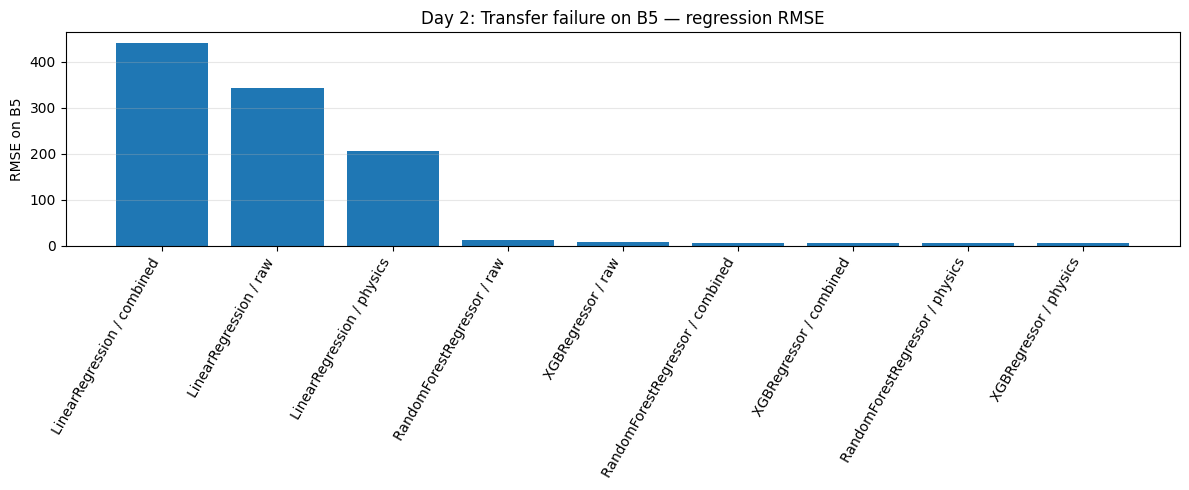

In [16]:
# Re-generate B5 regression RMSE comparison including XGBoost

plot_df = metrics_df[
    (metrics_df["task"] == "regression") &
    (metrics_df["split"] == "test_B5")
].copy()

plot_df["label"] = plot_df["model"] + " / " + plot_df["feature_set"]

plot_df = plot_df.sort_values("RMSE", ascending=False)

plt.figure(figsize=(12, 5))

plt.bar(
    plot_df["label"],
    plot_df["RMSE"]
)

plt.ylabel("RMSE on B5")
plt.title("Day 2: Transfer failure on B5 — regression RMSE")

plt.xticks(rotation=60, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "b5_regression_rmse_comparison_with_xgboost.png",
    dpi=200
)

plt.show()

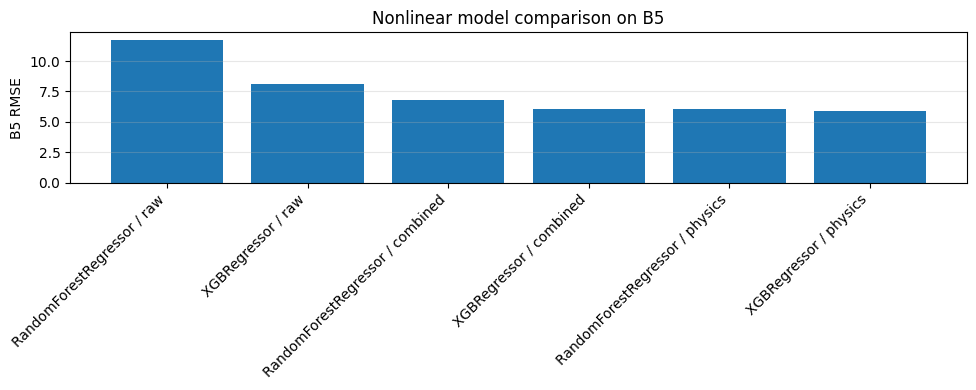

In [17]:
# Zoomed comparison for nonlinear models only

zoom_df = plot_df[
    plot_df["model"].isin([
        "RandomForestRegressor",
        "XGBRegressor"
    ])
]

plt.figure(figsize=(10, 4))

plt.bar(
    zoom_df["label"],
    zoom_df["RMSE"]
)

plt.ylabel("B5 RMSE")

plt.title("Nonlinear model comparison on B5")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "nonlinear_model_comparison.png",
    dpi=200
)

plt.show()

## 6. Lightweight classification baseline

This treats each concentration label as a class. This is useful when the transfer question is framed as level identification rather than continuous regression.

In [8]:
le = LabelEncoder()
le.fit(features['concentration'])

y_train_cls = le.transform(train_df['concentration'])
y_val_cls = le.transform(val_df['concentration'])
y_test_cls = le.transform(test_df['concentration'])

classifiers = {
    'LogisticRegression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ]),
    'RandomForestClassifier': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(n_estimators=300, random_state=42, min_samples_leaf=2, class_weight='balanced')),
    ]),
}

cls_metrics = []
cls_prediction_frames = []

for fs_name, cols in feature_sets.items():
    X_train = train_df[cols]
    X_val = val_df[cols]
    X_test = test_df[cols]

    for model_name, model in classifiers.items():
        model.fit(X_train, y_train_cls)
        fitted_models[('classification', model_name, fs_name)] = model

        for split_name, df_split, X_split, y_split in [
            ('validation_B4', val_df, X_val, y_val_cls),
            ('test_B5', test_df, X_test, y_test_cls),
        ]:
            pred = model.predict(X_split)
            cls_metrics.append({
                'task': 'classification',
                'model': model_name,
                'feature_set': fs_name,
                'split': split_name,
                'accuracy': accuracy_score(y_split, pred),
                'balanced_accuracy': balanced_accuracy_score(y_split, pred),
            })
            tmp = df_split[['filename', 'board', 'concentration', 'concentration_numeric', 'replicate']].copy()
            tmp['task'] = 'classification'
            tmp['model'] = model_name
            tmp['feature_set'] = fs_name
            tmp['split_eval'] = split_name
            tmp['y_true_label'] = le.inverse_transform(y_split)
            tmp['y_pred_label'] = le.inverse_transform(pred)
            cls_prediction_frames.append(tmp)

cls_metrics_df = pd.DataFrame(cls_metrics)
cls_preds_df = pd.concat(cls_prediction_frames, ignore_index=True)
cls_metrics_df.to_csv(RES_DIR / 'metrics_classification.csv', index=False)

display(cls_metrics_df.sort_values(['split', 'balanced_accuracy'], ascending=[True, False]))

,task,model,feature_set,split,accuracy,balanced_accuracy
7,classification,RandomForestClassifier,physics,test_B5,0.85,0.85
11,classification,RandomForestClassifier,combined,test_B5,0.80,0.80
3,classification,RandomForestClassifier,raw,test_B5,0.70,0.70
5,classification,LogisticRegression,physics,test_B5,0.20,0.20
9,classification,LogisticRegression,combined,test_B5,0.15,0.15
1,classification,LogisticRegression,raw,test_B5,0.10,0.10
10,classification,RandomForestClassifier,combined,validation_B4,0.90,0.90
2,classification,RandomForestClassifier,raw,validation_B4,0.85,0.85
6,classification,RandomForestClassifier,physics,validation_B4,0.65,0.65
0,classification,LogisticRegression,raw,validation_B4,0.30,0.30


## 7. Save combined metrics

In [9]:
metrics_all = pd.concat([metrics_df, cls_metrics_df], ignore_index=True, sort=False)
metrics_all.to_csv(RES_DIR / 'metrics.csv', index=False)
print(RES_DIR / 'metrics.csv')
display(metrics_all)

C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2\metrics.csv


,task,model,feature_set,split,MAE,RMSE,R2,accuracy,balanced_accuracy
0,regression,LinearRegression,raw,validation_B4,240.015982,242.037273,-70.008535,NaN,NaN
1,regression,LinearRegression,raw,test_B5,274.417526,341.825982,-140.630306,NaN,NaN
2,regression,RandomForestRegressor,raw,validation_B4,4.414111,5.069589,0.968848,NaN,NaN
3,regression,RandomForestRegressor,raw,test_B5,6.248075,11.766652,0.832177,NaN,NaN
4,regression,XGBRegressor,raw,validation_B4,5.902390,6.749274,0.944785,NaN,NaN
5,regression,XGBRegressor,raw,test_B5,4.980887,8.091797,0.920634,NaN,NaN
6,regression,LinearRegression,physics,validation_B4,35.184136,38.256671,-0.774028,NaN,NaN
7,regression,LinearRegression,physics,test_B5,176.348188,206.423216,-50.649144,NaN,NaN
8,regression,RandomForestRegressor,physics,validation_B4,3.477770,4.970322,0.970056,NaN,NaN
9,regression,RandomForestRegressor,physics,test_B5,3.479690,6.044794,0.955710,NaN,NaN


## 8. Figures

saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2\b5_regression_rmse_comparison.png


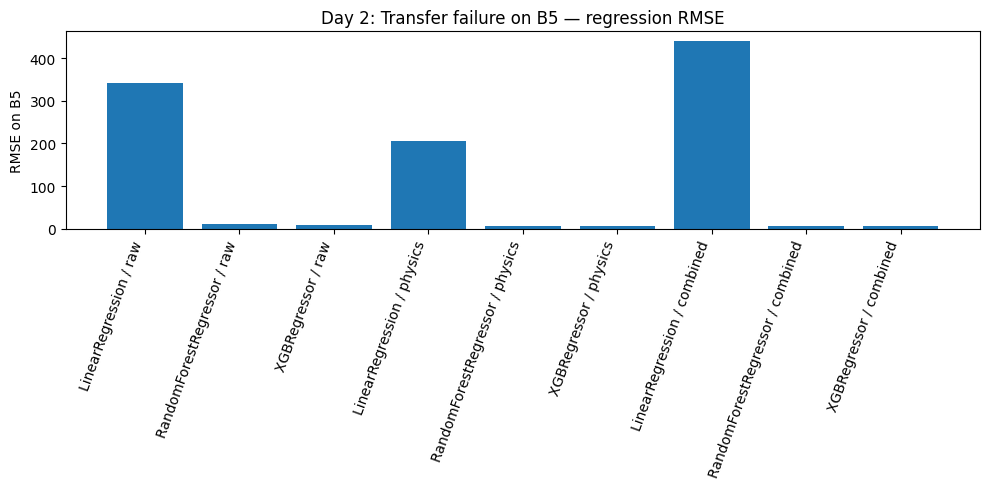

saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2\b5_prediction_vs_true_best_regressor.png


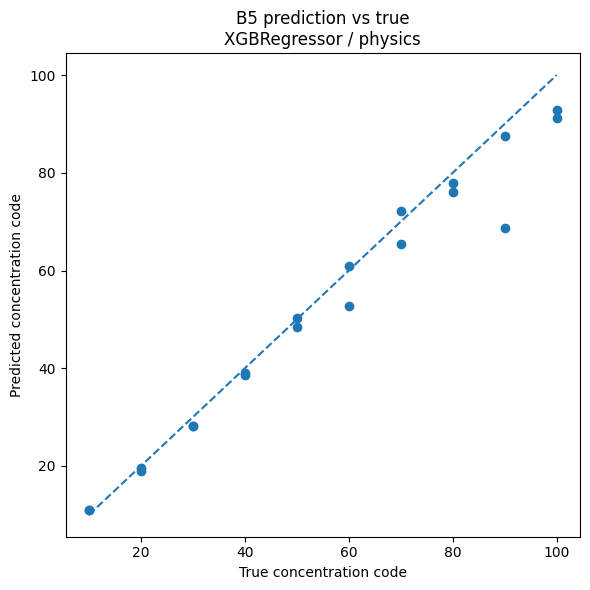

saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2\b5_error_by_concentration.png


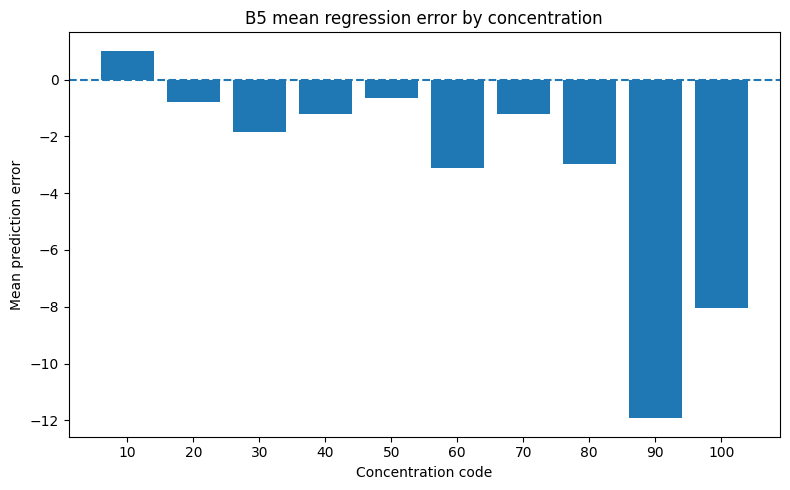

saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2\baseline_variation_s1_by_board.png


<Figure size 800x500 with 0 Axes>

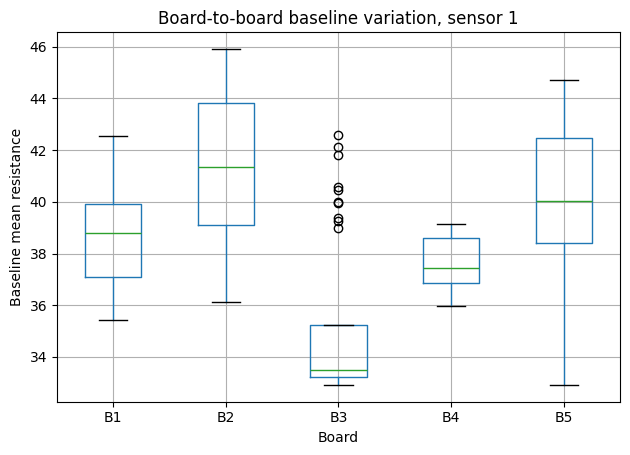

saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2\b5_confusion_matrix_best_classifier.png


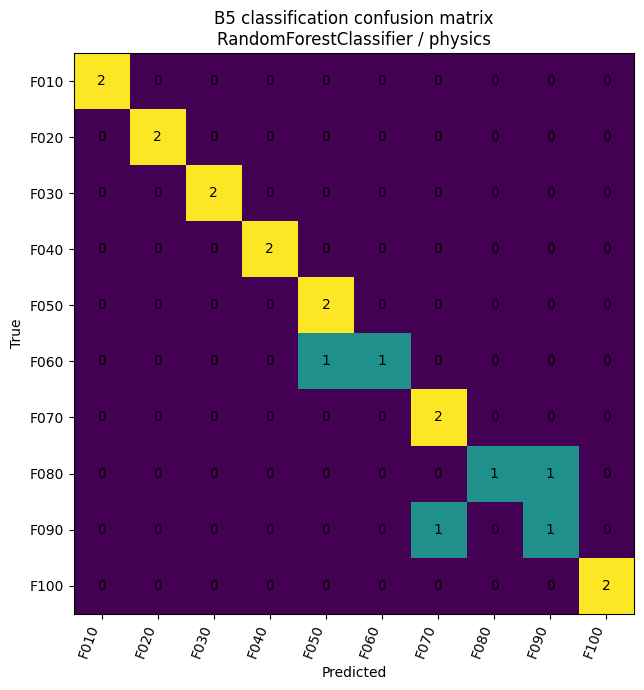

In [10]:
def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('saved:', path)
    plt.show()

# Regression metric comparison on B5
b5_reg = metrics_df[metrics_df['split'] == 'test_B5'].copy()
plt.figure(figsize=(10, 5))
labels = b5_reg['model'] + ' / ' + b5_reg['feature_set']
plt.bar(range(len(b5_reg)), b5_reg['RMSE'])
plt.xticks(range(len(b5_reg)), labels, rotation=70, ha='right')
plt.ylabel('RMSE on B5')
plt.title('Day 2: Transfer failure on B5 — regression RMSE')
savefig('b5_regression_rmse_comparison.png')

# Prediction vs true for best B5 regressor by RMSE
best_row = b5_reg.sort_values('RMSE').iloc[0]
best_pred = preds_df[
    (preds_df['split_eval'] == 'test_B5') &
    (preds_df['model'] == best_row['model']) &
    (preds_df['feature_set'] == best_row['feature_set'])
].copy()

plt.figure(figsize=(6, 6))
plt.scatter(best_pred['y_true'], best_pred['y_pred'])
lo = min(best_pred['y_true'].min(), best_pred['y_pred'].min())
hi = max(best_pred['y_true'].max(), best_pred['y_pred'].max())
plt.plot([lo, hi], [lo, hi], linestyle='--')
plt.xlabel('True concentration code')
plt.ylabel('Predicted concentration code')
plt.title(f"B5 prediction vs true\n{best_row['model']} / {best_row['feature_set']}")
savefig('b5_prediction_vs_true_best_regressor.png')

# Error by concentration
err_by_conc = best_pred.groupby('concentration_numeric')['error'].agg(['mean', 'std', 'count']).reset_index()
plt.figure(figsize=(8, 5))
plt.bar(err_by_conc['concentration_numeric'].astype(str), err_by_conc['mean'])
plt.axhline(0, linestyle='--')
plt.xlabel('Concentration code')
plt.ylabel('Mean prediction error')
plt.title('B5 mean regression error by concentration')
savefig('b5_error_by_concentration.png')

# Board-level raw baseline distributions, using sensor 1 as representative
plt.figure(figsize=(8, 5))
features.boxplot(column='s1_phys_baseline_mean', by='board')
plt.suptitle('')
plt.title('Board-to-board baseline variation, sensor 1')
plt.xlabel('Board')
plt.ylabel('Baseline mean resistance')
savefig('baseline_variation_s1_by_board.png')

# Classification confusion matrix for best B5 classifier
b5_cls = cls_metrics_df[cls_metrics_df['split'] == 'test_B5'].copy()
if not b5_cls.empty:
    best_cls = b5_cls.sort_values('balanced_accuracy', ascending=False).iloc[0]
    cm_df = cls_preds_df[
        (cls_preds_df['split_eval'] == 'test_B5') &
        (cls_preds_df['model'] == best_cls['model']) &
        (cls_preds_df['feature_set'] == best_cls['feature_set'])
    ].copy()
    labels_order = list(le.classes_)
    cm = confusion_matrix(cm_df['y_true_label'], cm_df['y_pred_label'], labels=labels_order)
    plt.figure(figsize=(8, 7))
    plt.imshow(cm)
    plt.xticks(range(len(labels_order)), labels_order, rotation=70, ha='right')
    plt.yticks(range(len(labels_order)), labels_order)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f"B5 classification confusion matrix\n{best_cls['model']} / {best_cls['feature_set']}")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center')
    savefig('b5_confusion_matrix_best_classifier.png')

## 9. RandomForest feature importance

Feature set: physics
Number of feature names: 88
Number of importances: 168
Using generic feature names instead.


,feature,importance
0,feature_82,0.182638
1,feature_83,0.171326
2,feature_94,0.126911
3,feature_127,0.115444
4,feature_126,0.114662
5,feature_93,0.109239
6,feature_149,0.060980
7,feature_148,0.035652
8,feature_81,0.013984
9,feature_138,0.007289


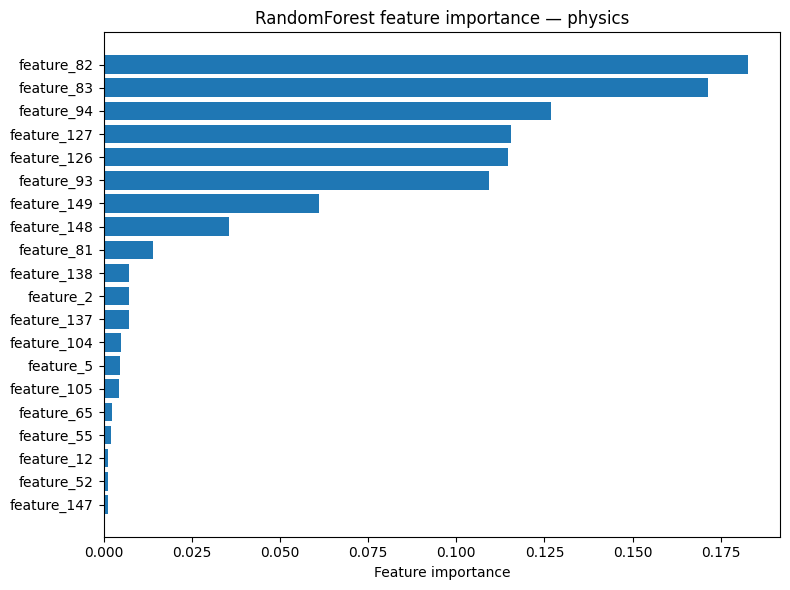

In [11]:
# Feature importance for best RandomForestRegressor on B5, if available.
# 9. RandomForest feature importance

rf_rows = metrics_df[
    metrics_df["model"].str.contains("RandomForest", case=False, na=False)
].copy()

if len(rf_rows) == 0:
    print("No RandomForest model found.")
else:
    rf_best = rf_rows.sort_values("RMSE").iloc[0]

    task = rf_best["task"]
    model_name = rf_best["model"]
    feature_set_name = rf_best["feature_set"]

    rf_model = fitted_models[(task, model_name, feature_set_name)]

    importances = rf_model.named_steps["model"].feature_importances_

    # Recover feature names safely
    if "preprocess" in rf_model.named_steps:
        try:
            feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
        except Exception:
            feature_names = feature_sets[feature_set_name]
    else:
        feature_names = feature_sets[feature_set_name]

    feature_names = list(feature_names)

    print("Feature set:", feature_set_name)
    print("Number of feature names:", len(feature_names))
    print("Number of importances:", len(importances))

    # Safety fallback
    if len(feature_names) != len(importances):
        print("WARNING: feature name length does not match importance length.")
        print("Using generic feature names instead.")
        feature_names = [f"feature_{i}" for i in range(len(importances))]

    fi = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    fi.to_csv(RES_DIR / "rf_feature_importance_best_b5.csv", index=False)

    display(fi.head(20))

    plt.figure(figsize=(8, 6))
    top_fi = fi.head(20).iloc[::-1]
    plt.barh(top_fi["feature"], top_fi["importance"])
    plt.xlabel("Feature importance")
    plt.title(f"RandomForest feature importance — {feature_set_name}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "rf_feature_importance_best_b5.png", dpi=200)
    plt.show()

Explained variance ratio: [0.25676558 0.23368855]
Total explained variance: 0.4904541285629198


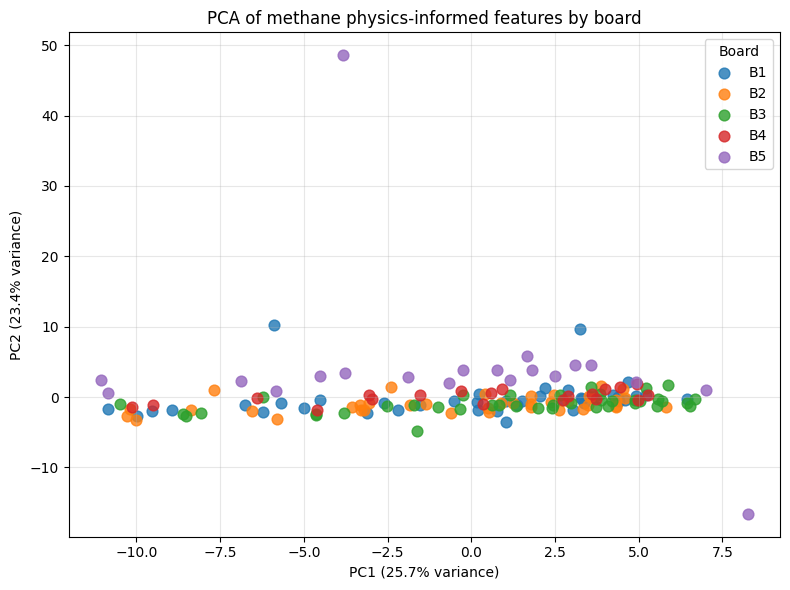

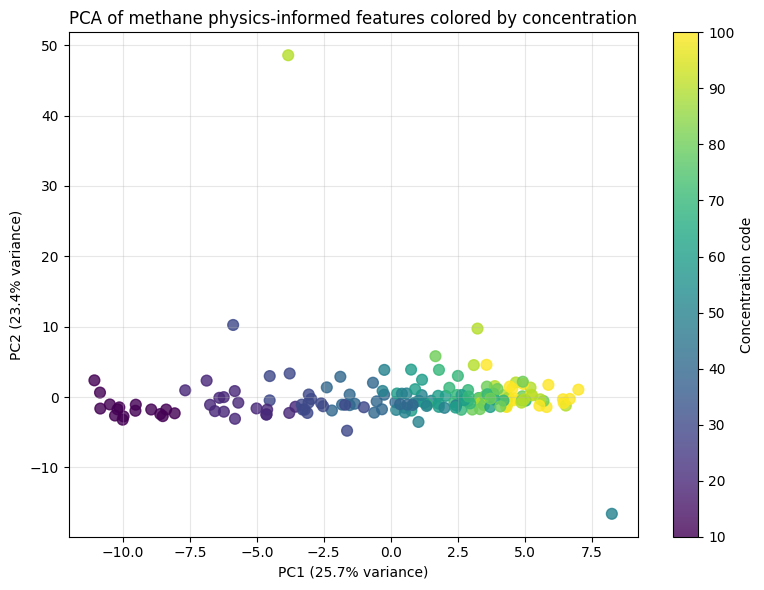

In [12]:
# 10. PCA visualization by board
# Goal: visualize board-to-board domain shift in feature space

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Choose feature set: physics is most meaningful for calibration transfer
pca_feature_set = "physics"
pca_cols = feature_sets[pca_feature_set]

X_pca = features[pca_cols].copy()
meta_pca = features[["board", "concentration"]].copy()

# Create numeric concentration code if it does not already exist
if "concentration_code" in features.columns:
    meta_pca["concentration_code"] = features["concentration_code"]
else:
    meta_pca["concentration_code"] = (
        meta_pca["concentration"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

# Handle missing values
X_pca = X_pca.replace([np.inf, -np.inf], np.nan)
X_pca = X_pca.fillna(X_pca.median(numeric_only=True))

# Standardize before PCA
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)

pca_df = meta_pca.copy()
pca_df["PC1"] = Z[:, 0]
pca_df["PC2"] = Z[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))

for board in sorted(pca_df["board"].unique()):
    sub = pca_df[pca_df["board"] == board]
    plt.scatter(
        sub["PC1"],
        sub["PC2"],
        label=board,
        alpha=0.8,
        s=60
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of methane physics-informed features by board")
plt.legend(title="Board")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "pca_physics_features_by_board.png", dpi=200)
plt.show()

# PCA visualization by concentration code

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["concentration_code"],
    alpha=0.8,
    s=60
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of methane physics-informed features colored by concentration")
plt.colorbar(scatter, label="Concentration code")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "pca_physics_features_by_concentration.png", dpi=200)
plt.show()

In [13]:
[x for x in globals().keys() if 'feature' in x.lower()]

['extract_features_one_channel',
 'extract_features_one_file',
 'feature_rows',
 'features',
 'feature_sets',
 'feature_set_name',
 'feature_names',
 'pca_feature_set']

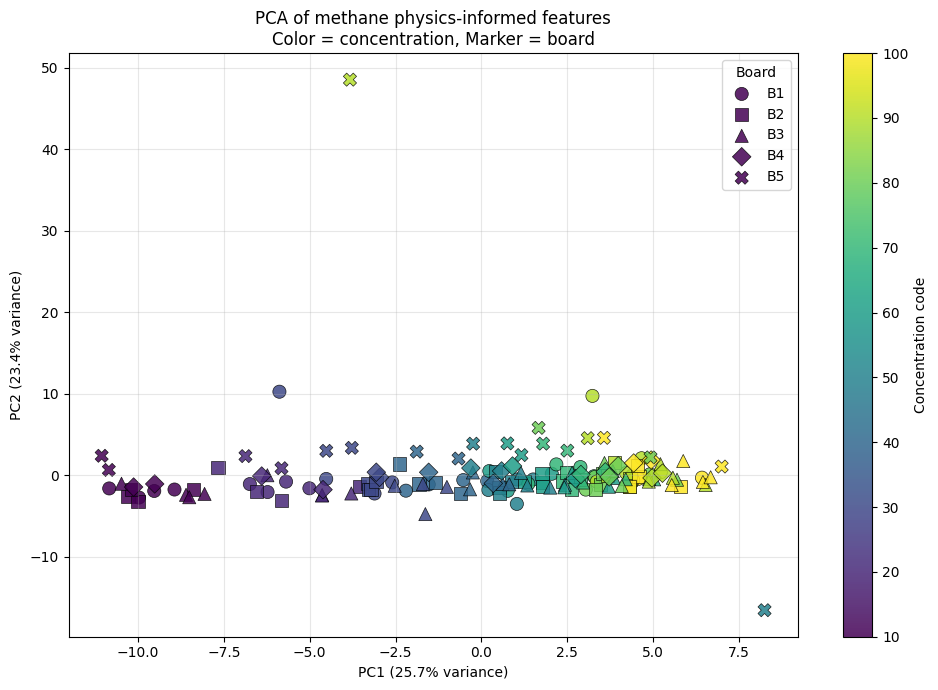

In [14]:
# 11. Combined PCA visualization
# color = concentration
# marker = board

import matplotlib.pyplot as plt

board_markers = {
    "B1": "o",
    "B2": "s",
    "B3": "^",
    "B4": "D",
    "B5": "X",
}

plt.figure(figsize=(10, 7))

for board in sorted(pca_df["board"].unique()):

    sub = pca_df[pca_df["board"] == board]

    scatter = plt.scatter(
        sub["PC1"],
        sub["PC2"],
        c=sub["concentration_code"],
        cmap="viridis",
        marker=board_markers.get(board, "o"),
        s=90,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
        label=board
    )

cbar = plt.colorbar(scatter)
cbar.set_label("Concentration code")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.title(
    "PCA of methane physics-informed features\n"
    "Color = concentration, Marker = board"
)

plt.legend(title="Board")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "pca_combined_board_concentration.png",
    dpi=200
)

plt.show()

## 10. Day 2 observations

Run the next cell after inspecting the metrics and plots. It writes `results/day2/day2_observations.md`.

In [15]:
best_b5_reg = b5_reg.sort_values('RMSE').iloc[0]
raw_b5 = b5_reg[b5_reg['feature_set'] == 'raw'].sort_values('RMSE').iloc[0]
phys_b5 = b5_reg[b5_reg['feature_set'] == 'physics'].sort_values('RMSE').iloc[0]
combined_b5 = b5_reg[b5_reg['feature_set'] == 'combined'].sort_values('RMSE').iloc[0]

if phys_b5['RMSE'] < raw_b5['RMSE']:
    phys_statement = 'Physics-informed features improved B5 RMSE relative to raw features.'
else:
    phys_statement = 'Physics-informed features did not improve B5 RMSE relative to raw features.'

obs = f"""# Day 2 Observations — Methane Calibration Transfer Baseline

## Scope

Day 2 built a methane-only baseline for UCI #361 Twin Gas Sensor Arrays using simple, interpretable models only.

## Split

- Train boards: B1, B2, B3
- Validation board: B4
- Test board: B5

## Feature sets

- Raw features: {len(raw_cols)}
- Physics-informed features: {len(phys_cols)}
- Combined features: {len(combined_cols)}

## Best B5 regression result

- Model: {best_b5_reg['model']}
- Feature set: {best_b5_reg['feature_set']}
- MAE: {best_b5_reg['MAE']:.4f}
- RMSE: {best_b5_reg['RMSE']:.4f}
- R²: {best_b5_reg['R2']:.4f}

## Raw vs physics-informed comparison on B5

Best raw-feature model:

- Model: {raw_b5['model']}
- RMSE: {raw_b5['RMSE']:.4f}
- R²: {raw_b5['R2']:.4f}

Best physics-informed model:

- Model: {phys_b5['model']}
- RMSE: {phys_b5['RMSE']:.4f}
- R²: {phys_b5['R2']:.4f}

Best combined-feature model:

- Model: {combined_b5['model']}
- RMSE: {combined_b5['RMSE']:.4f}
- R²: {combined_b5['R2']:.4f}

Conclusion: {phys_statement}

## Calibration-transfer interpretation

B5 is treated as a held-out target board. Poor B5 performance should not be hidden or optimized away at this stage. If validation on B4 is materially better than testing on B5, this supports the Day 1 visual finding that B5 has a stronger board-specific shift.

Likely causes of B5 transfer difficulty:

1. Board-specific baseline resistance offsets.
2. Sensor-to-sensor response gain differences.
3. Concentration-dependent nonlinear response mismatch.
4. Recovery dynamics that are similar in shape but shifted in scale or slope.

## Saved outputs

- `results/day2/feature_table_methane.csv`
- `results/day2/metrics.csv`
- `results/day2/metrics_regression.csv`
- `results/day2/metrics_classification.csv`
- `results/day2/predictions_b5.csv`
- `results/day2/rf_feature_importance_best_b5.csv`, if RandomForest was trained
- `figures/day2/*.png`

## Implication for Day 3

Day 3 should not introduce deep learning. The next logical step is few-shot target-board adaptation for B5 using a small number of B5 calibration examples, while keeping the same interpretable feature pipeline.
"""

out_path = RES_DIR / 'day2_observations.md'
out_path.write_text(obs, encoding='utf-8')
print(obs)
print('\nSaved:', out_path)

# Day 2 Observations — Methane Calibration Transfer Baseline

## Scope

Day 2 built a methane-only baseline for UCI #361 Twin Gas Sensor Arrays using simple, interpretable models only.

## Split

- Train boards: B1, B2, B3
- Validation board: B4
- Test board: B5

## Feature sets

- Raw features: 80
- Physics-informed features: 88
- Combined features: 168

## Best B5 regression result

- Model: XGBRegressor
- Feature set: physics
- MAE: 3.6183
- RMSE: 5.9375
- R²: 0.9573

## Raw vs physics-informed comparison on B5

Best raw-feature model:

- Model: XGBRegressor
- RMSE: 8.0918
- R²: 0.9206

Best physics-informed model:

- Model: XGBRegressor
- RMSE: 5.9375
- R²: 0.9573

Best combined-feature model:

- Model: XGBRegressor
- RMSE: 6.0816
- R²: 0.9552

Conclusion: Physics-informed features improved B5 RMSE relative to raw features.

## Calibration-transfer interpretation

B5 is treated as a held-out target board. Poor B5 performance should not be hidden or optimized away at this stage. If 